In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/biohub-cell-tracking-during-development/sample_submission.csv
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/7/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/47/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/17/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/81/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/19/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/22/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845

## Goal

In Chapter 19, I found that the current handcrafted features only weakly separate oracle-good candidates from oracle-bad candidates. The strongest signals (`is_near_border`, `patch_com_offset`, `sigma`) were still not strong enough to make ranking reliable.

In this chapter, I will engineer a new set of **3D patch features** around each LoG candidate. These features will describe the candidate not just in a single 2D slice, but across a small z-neighborhood. The hope is that real nuclei will have a more consistent 3D structure than false detections.

I will compute these new 3D features for the oracle-analysis candidate table and inspect whether they appear to separate oracle-good candidates more clearly.

In [2]:
!pip install -q zarr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 81.4 MB/s eta 0:00:00


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr
from skimage.feature import blob_log

competition_path = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development")
train_path = competition_path / "train"

sample_id = "44b6_12dfb391"
zarr_path = train_path / f"{sample_id}.zarr"
geff_path = train_path / f"{sample_id}.geff"

volume = zarr.open(zarr_path, mode="r")
image = volume["0"]

geff = zarr.open(geff_path, mode="r")

nodes_df = pd.DataFrame({
    "node_id": geff["nodes/ids"][:],
    "t": geff["nodes/props/t/values"][:],
    "z": geff["nodes/props/z/values"][:],
    "y": geff["nodes/props/y/values"][:],
    "x": geff["nodes/props/x/values"][:],
})

t = 40
frame_3d = image[t]

print("Loaded image shape:", image.shape)
print("Selected t:", t)
print("frame_3d shape:", frame_3d.shape)
print("GT nodes:", len(nodes_df))

Loaded image shape: (100, 64, 256, 256)
Selected t: 40
frame_3d shape: (64, 256, 256)
GT nodes: 788


## Step 1 — Load the Oracle Analysis Candidate Table

I will start from the candidate table created in Chapter 19. It should already contain:

- candidate coordinates (`z, y, x`)
- oracle label (`oracle_good`)
- current 2D handcrafted features
- nearest GT distance

I will also use the raw 3D frame for the same timestep.

In [4]:
def detect_blobs_log_3d_slicewise(
    frame_3d,
    min_sigma=2.5,
    max_sigma=3.5,
    num_sigma=3,
    threshold=0.15
):
    detections = []

    for z in range(frame_3d.shape[0]):
        slice_2d = frame_3d[z].astype(np.float32)
        s_min, s_max = slice_2d.min(), slice_2d.max()

        if s_max > s_min:
            slice_norm = (slice_2d - s_min) / (s_max - s_min)
        else:
            slice_norm = slice_2d

        blobs = blob_log(
            slice_norm,
            min_sigma=min_sigma,
            max_sigma=max_sigma,
            num_sigma=num_sigma,
            threshold=threshold
        )

        for blob in blobs:
            y, x, sigma = blob
            detections.append({
                "z": int(z),
                "y": int(round(y)),
                "x": int(round(x)),
                "sigma": float(sigma)
            })

    return pd.DataFrame(detections)


def add_center_intensity(frame_3d, pred_df):
    pred_df = pred_df.copy()
    pred_df["center_intensity"] = [
        float(frame_3d[int(r.z), int(r.y), int(r.x)])
        for r in pred_df.itertuples()
    ]
    return pred_df


def consolidate_candidates_3d(pred_df, radius=3.0, score_col="center_intensity"):
    work_df = pred_df.copy().sort_values(score_col, ascending=False).reset_index(drop=True)
    kept_rows = []

    while len(work_df) > 0:
        keep = work_df.iloc[0]
        kept_rows.append(keep)

        keep_point = np.array([keep["z"], keep["y"], keep["x"]], dtype=float)
        points = work_df[["z", "y", "x"]].to_numpy(dtype=float)
        dists = np.sqrt(((points - keep_point) ** 2).sum(axis=1))

        work_df = work_df[dists > radius].reset_index(drop=True)

    return pd.DataFrame(kept_rows).reset_index(drop=True)


def pairwise_distances_3d(gt_points, pred_points):
    gt = gt_points[:, None, :]
    pred = pred_points[None, :, :]
    return np.sqrt(((gt - pred) ** 2).sum(axis=2))


gt_nodes_t = nodes_df[nodes_df["t"] == t].copy().sort_values("z")
gt_points = gt_nodes_t[["z", "y", "x"]].to_numpy()

raw_df = detect_blobs_log_3d_slicewise(frame_3d)
raw_df = add_center_intensity(frame_3d, raw_df)

nms_df = consolidate_candidates_3d(raw_df, radius=3.0)

dist = pairwise_distances_3d(gt_points, nms_df[["z", "y", "x"]].to_numpy())

oracle_feature_df = nms_df.copy()
oracle_feature_df["nearest_gt_dist"] = dist.min(axis=0)
oracle_feature_df["oracle_good"] = oracle_feature_df["nearest_gt_dist"] <= 6

print("Raw candidates:", len(raw_df))
print("NMS candidates:", len(nms_df))
print("Oracle table rows:", len(oracle_feature_df))
print(oracle_feature_df["oracle_good"].value_counts())
oracle_feature_df.head()

Raw candidates: 1596
NMS candidates: 688
Oracle table rows: 688
oracle_good
False    677
True      11
Name: count, dtype: int64


,z,y,x,sigma,center_intensity,nearest_gt_dist,oracle_good
0,54.0,237.0,199.0,3.5,4348.0,84.107075,False
1,11.0,109.0,118.0,3.0,4263.0,20.904545,False
2,55.0,231.0,203.0,3.5,3789.0,85.562842,False
3,52.0,236.0,202.0,3.5,3597.0,85.358069,False
4,49.0,248.0,202.0,3.0,3314.0,89.760793,False


## Step 3 — Define a 3D Patch Extraction Helper

I will extract a small 3D cuboid centered on each candidate. This patch will let me summarize intensity structure above and below the candidate in z, as well as around it in x/y.

For now I will use:

- `z_radius = 2` → 5 z-slices total
- `xy_radius = 4` → 9×9 pixels per slice

In [5]:
def extract_3d_patch(volume, z, y, x, z_radius=2, xy_radius=4):
    """
    Extract a 3D patch centered at (z, y, x) with boundary clipping.
    
    Returns:
        patch: ndarray of shape (z_extent, y_extent, x_extent)
    """
    Z, Y, X = volume.shape
    
    z0 = max(0, z - z_radius)
    z1 = min(Z, z + z_radius + 1)
    y0 = max(0, y - xy_radius)
    y1 = min(Y, y + xy_radius + 1)
    x0 = max(0, x - xy_radius)
    x1 = min(X, x + xy_radius + 1)
    
    patch = volume[z0:z1, y0:y1, x0:x1]
    return patch

## Step 4 — Define 3D Patch Features

I want features that capture whether a candidate looks like a real 3D nucleus rather than a noisy local maximum.

I will compute:

### 3D intensity features
- `vol_mean`: mean intensity of the full 3D patch
- `vol_std`: standard deviation of the patch
- `vol_max`: max intensity in the patch
- `center_voxel`: intensity at the candidate center

### 3D center-vs-context features
- `center_minus_vol_mean`: center voxel minus full-patch mean
- `center_over_vol_mean`: center voxel divided by full-patch mean
- `peak_to_mean_ratio`: patch max divided by patch mean

### z-profile features
Using the candidate’s `(y, x)` location across nearby z slices:
- `z_line_mean`
- `z_line_std`
- `z_line_max`
- `z_peak_offset`: distance between candidate z and brightest z in local z-line

### slice-energy features
For each z slice in the local patch, compute slice mean intensity:
- `slice_mean_std`: variability across z slices
- `center_slice_minus_neighbor_mean`: how much brighter the center z slice is than nearby z slices

### 3D shape / concentration features
- `bright_fraction`: fraction of voxels above the 90th percentile of the patch
- `mass_center_offset_3d`: distance between the candidate center and the patch intensity center-of-mass

In [6]:
def compute_3d_patch_features(volume, z, y, x, z_radius=2, xy_radius=4, eps=1e-6):
    """
    Compute richer 3D features around a candidate point.
    
    Returns:
        dict of scalar features
    """
    patch = extract_3d_patch(volume, z, y, x, z_radius=z_radius, xy_radius=xy_radius)
    
    # Global patch stats
    vol_mean = float(patch.mean())
    vol_std = float(patch.std())
    vol_max = float(patch.max())
    
    # Candidate-centered coordinates inside clipped patch
    z0 = max(0, z - z_radius)
    y0 = max(0, y - xy_radius)
    x0 = max(0, x - xy_radius)
    
    zc = z - z0
    yc = y - y0
    xc = x - x0
    
    center_voxel = float(patch[zc, yc, xc])
    
    # Ratios / contrasts
    center_minus_vol_mean = center_voxel - vol_mean
    center_over_vol_mean = center_voxel / (vol_mean + eps)
    peak_to_mean_ratio = vol_max / (vol_mean + eps)
    
    # z-line through the candidate x/y
    z_line = patch[:, yc, xc].astype(float)
    z_line_mean = float(z_line.mean())
    z_line_std = float(z_line.std())
    z_line_max = float(z_line.max())
    z_peak_local = int(np.argmax(z_line))
    z_peak_offset = abs(z_peak_local - zc)
    
    # Slice means across z
    slice_means = patch.mean(axis=(1, 2)).astype(float)
    slice_mean_std = float(slice_means.std())
    
    if len(slice_means) > 1:
        neighbor_means = np.delete(slice_means, zc)
        center_slice_minus_neighbor_mean = float(slice_means[zc] - neighbor_means.mean())
    else:
        center_slice_minus_neighbor_mean = 0.0
    
    # Bright fraction
    q90 = np.percentile(patch, 90)
    bright_fraction = float((patch >= q90).mean())
    
    # 3D center of mass (intensity-weighted)
    patch_float = patch.astype(float)
    total_mass = patch_float.sum()
    if total_mass > 0:
        zz, yy, xx = np.indices(patch.shape)
        com_z = (zz * patch_float).sum() / total_mass
        com_y = (yy * patch_float).sum() / total_mass
        com_x = (xx * patch_float).sum() / total_mass
        mass_center_offset_3d = float(
            np.sqrt((com_z - zc)**2 + (com_y - yc)**2 + (com_x - xc)**2)
        )
    else:
        mass_center_offset_3d = np.nan
    
    return {
        "vol_mean": vol_mean,
        "vol_std": vol_std,
        "vol_max": vol_max,
        "center_voxel": center_voxel,
        "center_minus_vol_mean": center_minus_vol_mean,
        "center_over_vol_mean": center_over_vol_mean,
        "peak_to_mean_ratio": peak_to_mean_ratio,
        "z_line_mean": z_line_mean,
        "z_line_std": z_line_std,
        "z_line_max": z_line_max,
        "z_peak_offset": z_peak_offset,
        "slice_mean_std": slice_mean_std,
        "center_slice_minus_neighbor_mean": center_slice_minus_neighbor_mean,
        "bright_fraction": bright_fraction,
        "mass_center_offset_3d": mass_center_offset_3d,
    }

## Step 5 — Compute 3D Patch Features for Every Candidate

Now I will compute these new 3D features for every candidate in the oracle-analysis table.

In [7]:
feature_rows_3d = []

for _, row in oracle_feature_df.iterrows():
    z, y, x = int(row["z"]), int(row["y"]), int(row["x"])
    feats = compute_3d_patch_features(frame_3d, z, y, x, z_radius=2, xy_radius=4)
    feature_rows_3d.append(feats)

feature_3d_df = pd.DataFrame(feature_rows_3d)

print("3D feature rows:", len(feature_3d_df))
feature_3d_df.head()

3D feature rows: 688


,vol_mean,vol_std,vol_max,center_voxel,center_minus_vol_mean,center_over_vol_mean,peak_to_mean_ratio,z_line_mean,z_line_std,z_line_max,z_peak_offset,slice_mean_std,center_slice_minus_neighbor_mean,bright_fraction,mass_center_offset_3d
0,2801.607407,780.782394,4393.0,4348.0,1546.392593,1.551966,1.568028,3784.2,521.181504,4348.0,0,265.519963,380.922840,0.101235,0.170337
1,1957.898765,794.194358,4276.0,4263.0,2305.101235,2.177334,2.183974,3287.0,834.895922,4263.0,0,377.813658,577.225309,0.101235,0.146445
2,2444.402469,738.551200,4144.0,3789.0,1344.597531,1.550072,1.695302,3083.6,557.128208,3789.0,0,359.908902,415.006173,0.101235,0.337775
3,2497.777778,829.848899,4393.0,3597.0,1099.222222,1.440080,1.758763,3155.8,633.664391,3796.0,1,472.348945,222.546296,0.101235,0.312739
4,2227.590123,386.833316,3314.0,3314.0,1086.409877,1.487706,1.487706,2886.0,358.588901,3314.0,0,116.621934,160.790123,0.101235,0.095375


In [8]:
oracle_feature_3d_df = pd.concat(
    [oracle_feature_df.reset_index(drop=True), feature_3d_df.reset_index(drop=True)],
    axis=1
)

print("Merged candidate table shape:", oracle_feature_3d_df.shape)
oracle_feature_3d_df.head()

Merged candidate table shape: (688, 22)


,z,y,x,sigma,center_intensity,nearest_gt_dist,oracle_good,vol_mean,vol_std,vol_max,...,center_over_vol_mean,peak_to_mean_ratio,z_line_mean,z_line_std,z_line_max,z_peak_offset,slice_mean_std,center_slice_minus_neighbor_mean,bright_fraction,mass_center_offset_3d
0,54.0,237.0,199.0,3.5,4348.0,84.107075,False,2801.607407,780.782394,4393.0,...,1.551966,1.568028,3784.2,521.181504,4348.0,0,265.519963,380.922840,0.101235,0.170337
1,11.0,109.0,118.0,3.0,4263.0,20.904545,False,1957.898765,794.194358,4276.0,...,2.177334,2.183974,3287.0,834.895922,4263.0,0,377.813658,577.225309,0.101235,0.146445
2,55.0,231.0,203.0,3.5,3789.0,85.562842,False,2444.402469,738.551200,4144.0,...,1.550072,1.695302,3083.6,557.128208,3789.0,0,359.908902,415.006173,0.101235,0.337775
3,52.0,236.0,202.0,3.5,3597.0,85.358069,False,2497.777778,829.848899,4393.0,...,1.440080,1.758763,3155.8,633.664391,3796.0,1,472.348945,222.546296,0.101235,0.312739
4,49.0,248.0,202.0,3.0,3314.0,89.760793,False,2227.590123,386.833316,3314.0,...,1.487706,1.487706,2886.0,358.588901,3314.0,0,116.621934,160.790123,0.101235,0.095375


## Step 7 — Compare Oracle-Good vs Oracle-Bad on New 3D Features

I will compare the distributions of these new 3D features for:
- `oracle_good == True`
- `oracle_good == False`

This will tell me whether the 3D features provide stronger separation than the earlier 2D handcrafted features.

In [9]:
new_3d_features = [
    "vol_mean",
    "vol_std",
    "vol_max",
    "center_voxel",
    "center_minus_vol_mean",
    "center_over_vol_mean",
    "peak_to_mean_ratio",
    "z_line_mean",
    "z_line_std",
    "z_line_max",
    "z_peak_offset",
    "slice_mean_std",
    "center_slice_minus_neighbor_mean",
    "bright_fraction",
    "mass_center_offset_3d",
]

group_stats_3d = (
    oracle_feature_3d_df
    .groupby("oracle_good")[new_3d_features]
    .agg(["mean", "median", "std"])
)

group_stats_3d

vol_mean                              vol_std              \
                    mean       median         std        mean      median   
oracle_good                                                                 
False        1379.008949  1377.432099  324.628203  286.292788  274.671598   
True         1507.728620  1576.535802  273.589644  270.002440  253.940380   

                             vol_max                     center_voxel  ...  \
                    std         mean  median         std         mean  ...   
oracle_good                                                            ...   
False        106.174371  1978.957164  1992.0  482.141395  1803.063516  ...   
True          94.928464  2067.909091  2203.0  347.831699  1811.909091  ...   

            slice_mean_std center_slice_minus_neighbor_mean              \
                       std                             mean      median   
oracle_good                                                               
False            98.810758                       205.410446  210.033951   
True            109.235629                       136.382997  111.543210   

                        bright_fraction                      \
                    std            mean    median       std   
oracle_good                                                   
False        113.872048        0.101841  0.101235  0.001165   
True         113.094566        0.101684  0.101235  0.001489   

            mass_center_offset_3d                      
                             mean    median       std  
oracle_good                                            
False                    0.370577  0.211438  0.480996  
True                     0.212979  0.180902  0.119001  

[2 rows x 45 columns]

## Step 8 — Compute Separation Strength for New 3D Features

As in Chapter 19, I will compute a standardized mean difference (SMD) for each feature:

\[
\text{SMD} = \frac{\mu_{\text{good}} - \mu_{\text{bad}}}{\sigma_{\text{all}}}
\]

A larger absolute SMD means stronger separation between oracle-good and oracle-bad candidates.

In [10]:
separation_rows_3d = []

good_mask = oracle_feature_3d_df["oracle_good"] == True
bad_mask = oracle_feature_3d_df["oracle_good"] == False

for feat in new_3d_features:
    vals_good = oracle_feature_3d_df.loc[good_mask, feat].dropna()
    vals_bad = oracle_feature_3d_df.loc[bad_mask, feat].dropna()
    vals_all = oracle_feature_3d_df[feat].dropna()
    
    mean_good = vals_good.mean()
    mean_bad = vals_bad.mean()
    std_all = vals_all.std()
    
    smd = (mean_good - mean_bad) / (std_all + 1e-6)
    
    if mean_good > mean_bad:
        direction = "higher in oracle_good"
    else:
        direction = "lower in oracle_good"
    
    separation_rows_3d.append({
        "feature": feat,
        "mean_good": mean_good,
        "mean_bad": mean_bad,
        "smd": smd,
        "abs_smd": abs(smd),
        "direction_for_good": direction
    })

separation_3d_df = (
    pd.DataFrame(separation_rows_3d)
    .sort_values("abs_smd", ascending=False)
    .reset_index(drop=True)
)

separation_3d_df

,feature,mean_good,mean_bad,smd,abs_smd,direction_for_good
0,center_over_vol_mean,1.200245,1.311020,-0.813340,0.813340,lower in oracle_good
1,center_slice_minus_neighbor_mean,136.382997,205.410446,-0.604935,0.604935,lower in oracle_good
2,center_minus_vol_mean,304.180471,424.054566,-0.596648,0.596648,lower in oracle_good
3,z_peak_offset,0.818182,0.440177,0.552128,0.552128,higher in oracle_good
4,vol_mean,1507.728620,1379.008949,0.397149,0.397149,higher in oracle_good
5,peak_to_mean_ratio,1.378551,1.443306,-0.369596,0.369596,lower in oracle_good
6,mass_center_offset_3d,0.212979,0.370577,-0.329872,0.329872,lower in oracle_good
7,slice_mean_std,180.529666,208.955301,-0.287235,0.287235,lower in oracle_good
8,z_line_std,232.075377,263.960091,-0.261530,0.261530,lower in oracle_good
9,z_line_mean,1667.727273,1570.626563,0.256369,0.256369,higher in oracle_good


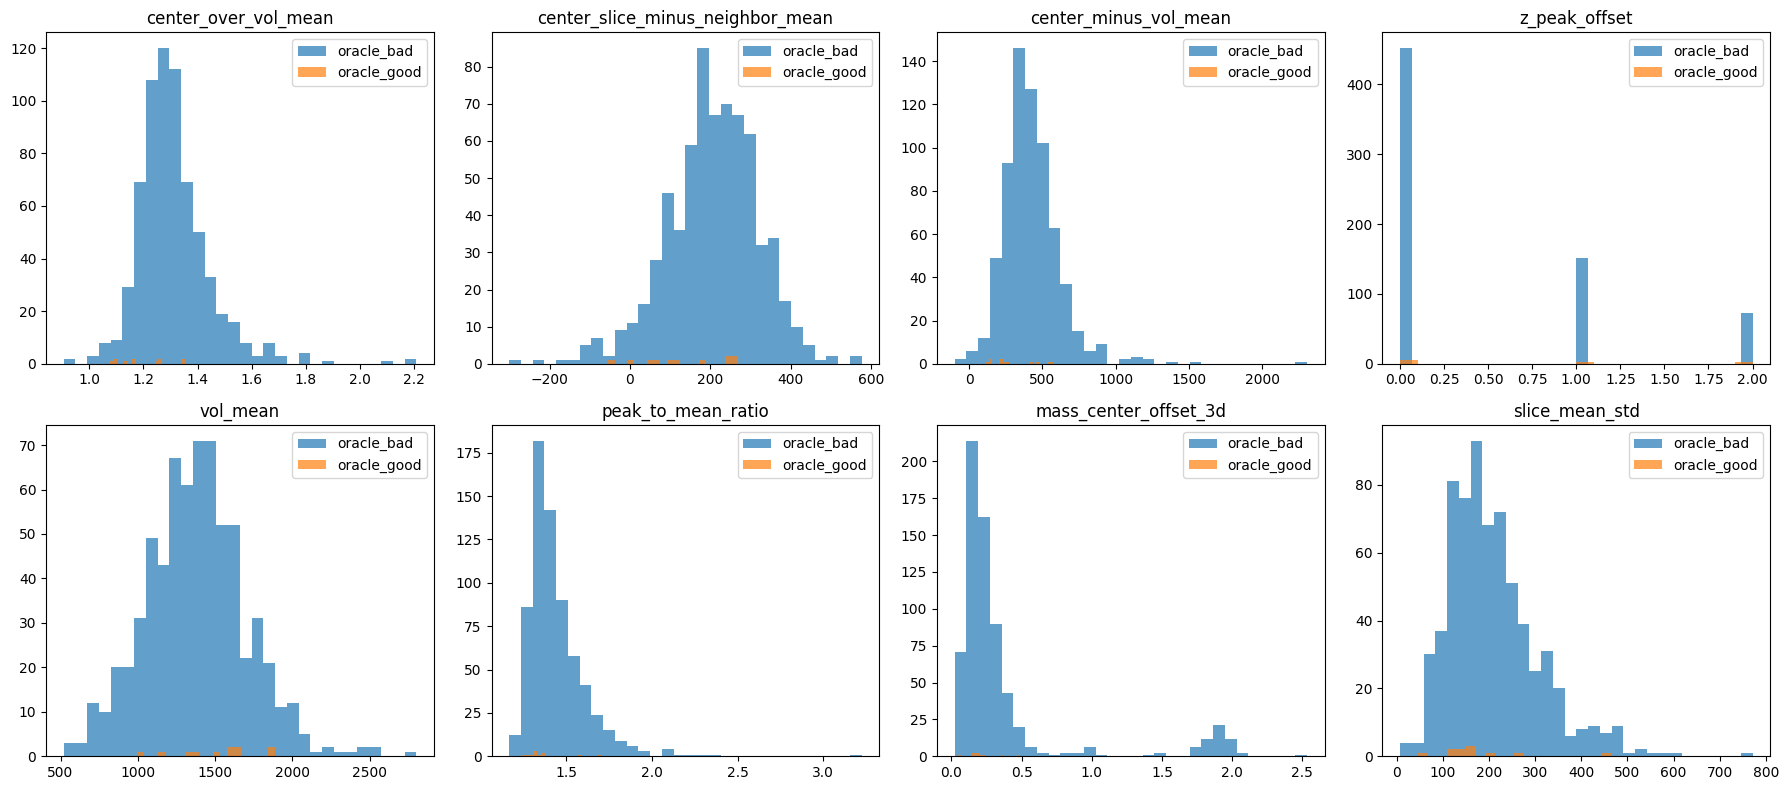

In [11]:
top_3d_feats = separation_3d_df.head(8)["feature"].tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for ax, feat in zip(axes, top_3d_feats):
    vals_bad = oracle_feature_3d_df.loc[~good_mask, feat].dropna()
    vals_good = oracle_feature_3d_df.loc[good_mask, feat].dropna()
    
    ax.hist(vals_bad, bins=30, alpha=0.7, label="oracle_bad")
    ax.hist(vals_good, bins=20, alpha=0.7, label="oracle_good")
    ax.set_title(feat)
    ax.legend()

for ax in axes[len(top_3d_feats):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Step 10 — Compare Old vs New Feature Separation

Now I want to compare the best old features from Chapter 19 against the best new 3D features from this chapter.

If the 3D features show larger separation than the old features, that means they are worth bringing into the ranking model.

In [12]:
# Compare new 3D features only
separation_3d_df.sort_values("abs_smd", ascending=False).head(20)

,feature,mean_good,mean_bad,smd,abs_smd,direction_for_good
0,center_over_vol_mean,1.200245,1.311020,-0.813340,0.813340,lower in oracle_good
1,center_slice_minus_neighbor_mean,136.382997,205.410446,-0.604935,0.604935,lower in oracle_good
2,center_minus_vol_mean,304.180471,424.054566,-0.596648,0.596648,lower in oracle_good
3,z_peak_offset,0.818182,0.440177,0.552128,0.552128,higher in oracle_good
4,vol_mean,1507.728620,1379.008949,0.397149,0.397149,higher in oracle_good
5,peak_to_mean_ratio,1.378551,1.443306,-0.369596,0.369596,lower in oracle_good
6,mass_center_offset_3d,0.212979,0.370577,-0.329872,0.329872,lower in oracle_good
7,slice_mean_std,180.529666,208.955301,-0.287235,0.287235,lower in oracle_good
8,z_line_std,232.075377,263.960091,-0.261530,0.261530,lower in oracle_good
9,z_line_mean,1667.727273,1570.626563,0.256369,0.256369,higher in oracle_good


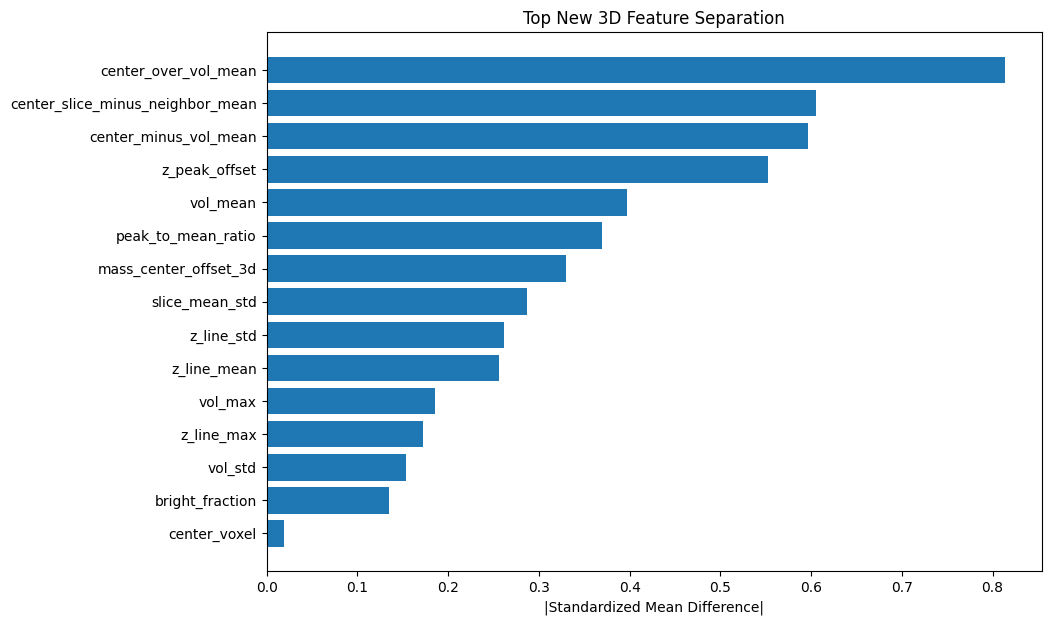

In [13]:
top_3d = separation_3d_df.sort_values("abs_smd", ascending=False).head(15)

plt.figure(figsize=(10, 7))
plt.barh(top_3d["feature"], top_3d["abs_smd"])
plt.gca().invert_yaxis()
plt.xlabel("|Standardized Mean Difference|")
plt.title("Top New 3D Feature Separation")
plt.show()

## Step 12 — Inspect Oracle-Good Candidates Under the New 3D Features

I want to look directly at the oracle-good candidates and see what their new 3D features look like.

In [14]:
oracle_good_3d = (
    oracle_feature_3d_df[oracle_feature_3d_df["oracle_good"]]
    .sort_values("nearest_gt_dist")
)

oracle_good_3d[
    ["z", "y", "x", "nearest_gt_dist"] + top_3d_feats[:6]
].head(20)

,z,y,x,nearest_gt_dist,center_over_vol_mean,center_slice_minus_neighbor_mean,center_minus_vol_mean,z_peak_offset,vol_mean,peak_to_mean_ratio
62,36.0,149.0,36.0,0.000000,1.256308,244.885802,479.439506,0,1870.560494,1.277692
114,26.0,197.0,71.0,1.414214,1.352115,269.024691,573.701235,0,1629.298765,1.352115
625,8.0,235.0,55.0,2.000000,1.098002,57.123457,112.550617,1,1148.449383,1.316558
187,35.0,34.0,204.0,3.000000,1.253697,270.385802,412.407407,0,1625.592593,1.315828
359,32.0,113.0,115.0,3.000000,1.158011,181.509259,238.787654,1,1511.212346,1.327411
313,25.0,199.0,75.0,3.316625,1.141004,111.543210,225.283951,1,1597.716049,1.378843
476,39.0,149.0,38.0,3.605551,1.160987,-53.595679,217.148148,2,1348.851852,1.710344
630,5.0,238.0,56.0,4.358899,1.261147,64.163580,259.874074,0,995.125926,1.302348
150,35.0,30.0,198.0,4.582576,1.346623,246.012346,546.464198,0,1576.535802,1.362481
497,24.0,195.0,69.0,4.690416,1.100491,104.256173,139.985185,2,1393.014815,1.581462


## Step 13 — Inspect the Worst Oracle-Good Candidates

These are candidates that are still oracle-good (within match radius of GT), but might look weak according to the new 3D features. This helps identify whether some true nuclei are inherently difficult or atypical.

In [15]:
oracle_good_3d.sort_values("nearest_gt_dist", ascending=False)[
    ["z", "y", "x", "nearest_gt_dist"] + top_3d_feats[:6]
].head(20)

,z,y,x,nearest_gt_dist,center_over_vol_mean,center_slice_minus_neighbor_mean,center_minus_vol_mean,z_peak_offset,vol_mean,peak_to_mean_ratio
192,44.0,78.0,161.0,5.916080,1.074308,4.904321,140.343210,2,1888.656790,1.238976
497,24.0,195.0,69.0,4.690416,1.100491,104.256173,139.985185,2,1393.014815,1.581462
150,35.0,30.0,198.0,4.582576,1.346623,246.012346,546.464198,0,1576.535802,1.362481
630,5.0,238.0,56.0,4.358899,1.261147,64.163580,259.874074,0,995.125926,1.302348
476,39.0,149.0,38.0,3.605551,1.160987,-53.595679,217.148148,2,1348.851852,1.710344
313,25.0,199.0,75.0,3.316625,1.141004,111.543210,225.283951,1,1597.716049,1.378843
187,35.0,34.0,204.0,3.000000,1.253697,270.385802,412.407407,0,1625.592593,1.315828
359,32.0,113.0,115.0,3.000000,1.158011,181.509259,238.787654,1,1511.212346,1.327411
625,8.0,235.0,55.0,2.000000,1.098002,57.123457,112.550617,1,1148.449383,1.316558
114,26.0,197.0,71.0,1.414214,1.352115,269.024691,573.701235,0,1629.298765,1.352115


## Step 14 — Visualize Example Oracle-Good vs Oracle-Bad Candidates

Finally, I will visually compare a few oracle-good and oracle-bad candidates to see whether the new 3D features correspond to visible structural differences.

In [16]:
def show_candidate_patch_grid(volume, candidate_df, title_prefix="", n=6, z_radius=2, xy_radius=8):
    """
    Show center z-slice patches for a few candidates.
    """
    sample_df = candidate_df.head(n).copy()
    
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.ravel()
    
    for ax, (_, row) in zip(axes, sample_df.iterrows()):
        z, y, x = int(row["z"]), int(row["y"]), int(row["x"])
        patch = extract_3d_patch(volume, z, y, x, z_radius=z_radius, xy_radius=xy_radius)
        center_slice = patch[patch.shape[0] // 2]
        
        ax.imshow(center_slice, cmap="gray")
        ax.set_title(f"{title_prefix} z={z}, y={y}, x={x}")
        ax.axis("off")
    
    for ax in axes[len(sample_df):]:
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()

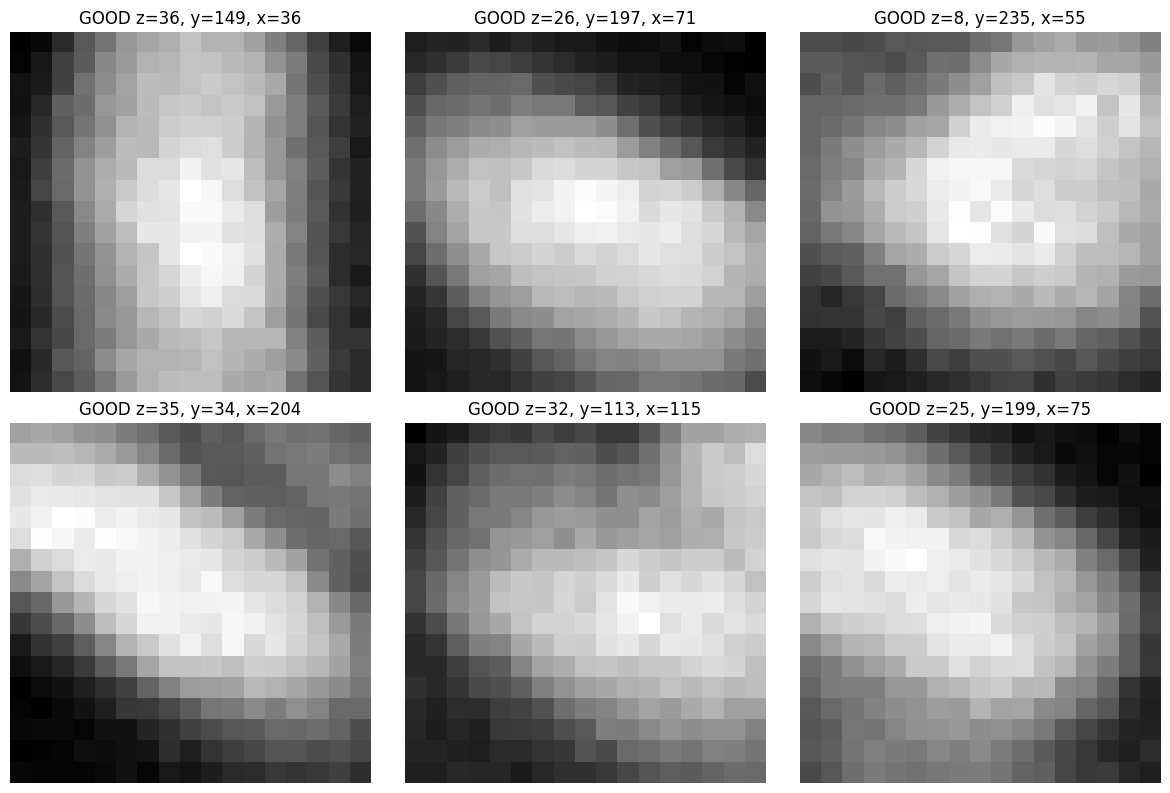

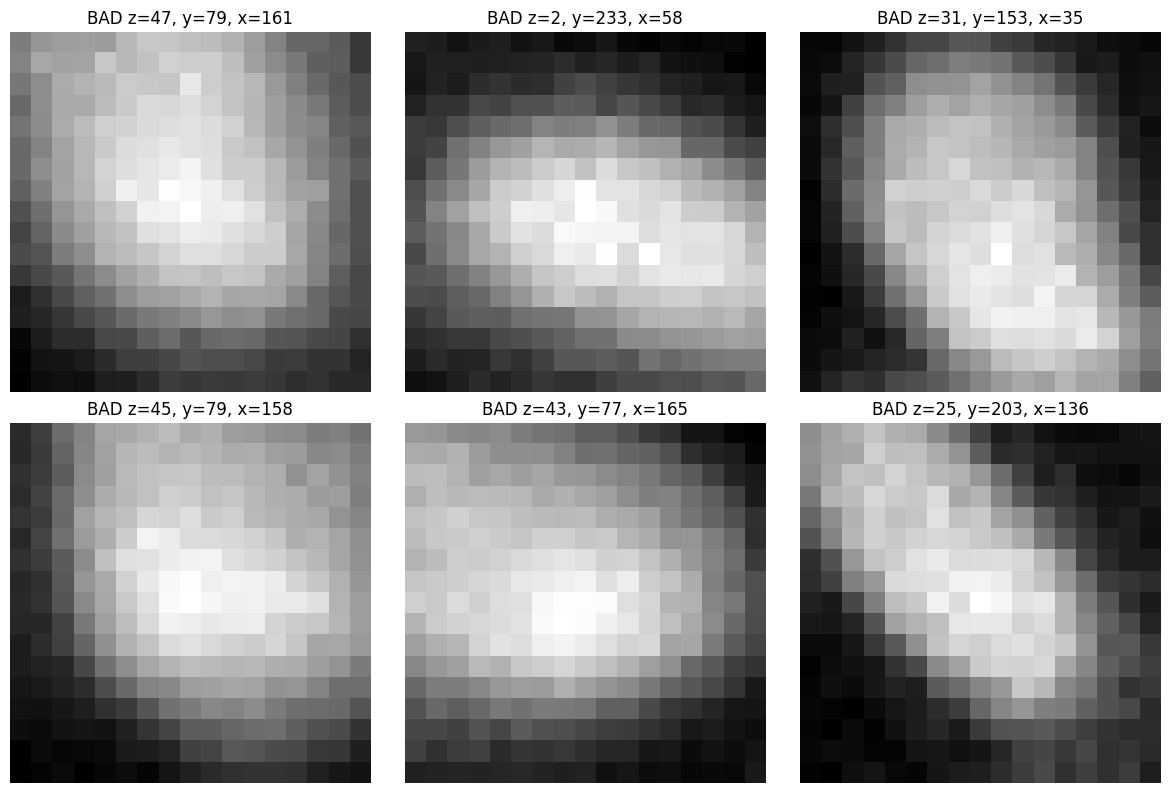

In [17]:
good_examples = oracle_feature_3d_df[oracle_feature_3d_df["oracle_good"]].sort_values("nearest_gt_dist")
bad_examples = oracle_feature_3d_df[~oracle_feature_3d_df["oracle_good"]].sort_values("nearest_gt_dist")

show_candidate_patch_grid(frame_3d, good_examples, title_prefix="GOOD", n=6)
show_candidate_patch_grid(frame_3d, bad_examples, title_prefix="BAD", n=6)

## Step 15 — Summarize the New 3D Feature Experiment

I will summarize the strongest new 3D features by their oracle-good vs oracle-bad separation.

In [18]:
chapter20_summary = separation_3d_df.copy()
chapter20_summary.head(15)

,feature,mean_good,mean_bad,smd,abs_smd,direction_for_good
0,center_over_vol_mean,1.200245,1.311020,-0.813340,0.813340,lower in oracle_good
1,center_slice_minus_neighbor_mean,136.382997,205.410446,-0.604935,0.604935,lower in oracle_good
2,center_minus_vol_mean,304.180471,424.054566,-0.596648,0.596648,lower in oracle_good
3,z_peak_offset,0.818182,0.440177,0.552128,0.552128,higher in oracle_good
4,vol_mean,1507.728620,1379.008949,0.397149,0.397149,higher in oracle_good
5,peak_to_mean_ratio,1.378551,1.443306,-0.369596,0.369596,lower in oracle_good
6,mass_center_offset_3d,0.212979,0.370577,-0.329872,0.329872,lower in oracle_good
7,slice_mean_std,180.529666,208.955301,-0.287235,0.287235,lower in oracle_good
8,z_line_std,232.075377,263.960091,-0.261530,0.261530,lower in oracle_good
9,z_line_mean,1667.727273,1570.626563,0.256369,0.256369,higher in oracle_good
